In [1]:
!pip install tensorflow opencv-python matplotlib scikit-learn

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [13]:
TRAIN_PATH = "chest_xray/train"

VAL_PATH = "chest_xray/val"

TEST_PATH = "chest_xray/test"

IMG_SIZE = 128

In [14]:
def load_data(data_path):

    data = []
    labels = []

    for label in os.listdir(data_path):

        label_path = os.path.join(data_path, label)

        # Skip if not folder
        if not os.path.isdir(label_path):
            continue

        for image_name in os.listdir(label_path):

            image_path = os.path.join(label_path, image_name)

            # Skip folders accidentally inside
            if not os.path.isfile(image_path):
                continue

            try:
                img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

                img = cv2.resize(img, (128, 128))

                img = img / 255.0

                data.append(img)

                labels.append(label)

            except Exception as e:
                print("Error loading:", image_path)

    return np.array(data), np.array(labels)

In [15]:
print("Loading Training Data...")
X_train, y_train = load_data(TRAIN_PATH)

print("Loading Validation Data...")
X_val, y_val = load_data(VAL_PATH)

print("Loading Testing Data...")
X_test, y_test = load_data(TEST_PATH)

print("Dataset Loaded Successfully!")

Loading Training Data...
Error loading: chest_xray/train\NORMAL\.DS_Store
Error loading: chest_xray/train\PNEUMONIA\.DS_Store
Loading Validation Data...
Error loading: chest_xray/val\NORMAL\.DS_Store
Error loading: chest_xray/val\PNEUMONIA\.DS_Store
Loading Testing Data...
Dataset Loaded Successfully!


In [16]:
print("X_train Shape:", X_train.shape)

print("X_val Shape:", X_val.shape)

print("X_test Shape:", X_test.shape)

X_train Shape: (5216, 128, 128)
X_val Shape: (16, 128, 128)
X_test Shape: (624, 128, 128)


In [17]:
X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

X_val = X_val.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

In [18]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)

y_val = encoder.transform(y_val)

y_test = encoder.transform(y_test)

y_train = to_categorical(y_train)

y_val = to_categorical(y_val)

y_test = to_categorical(y_test)

print("Classes:", encoder.classes_)

Classes: ['NORMAL' 'PNEUMONIA']


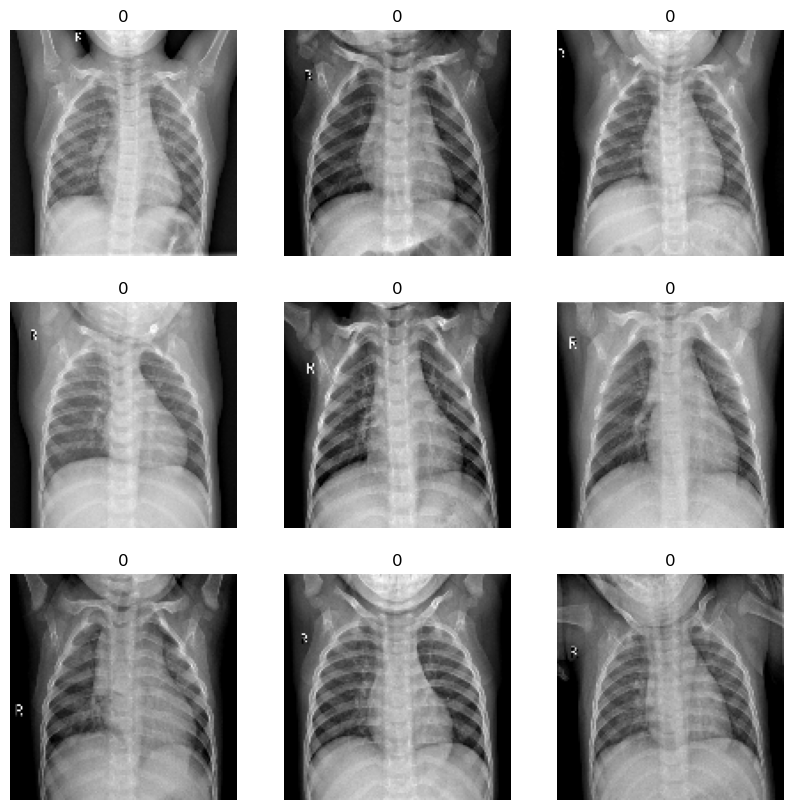

In [19]:
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')

    plt.title(np.argmax(y_train[i]))

    plt.axis("off")

plt.show()

In [20]:
model = Sequential()

# First CNN Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(IMG_SIZE, IMG_SIZE, 1)
))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

# Second CNN Layer
model.add(Conv2D(64, (3,3), activation='relu'))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

# Third CNN Layer
model.add(Conv2D(128, (3,3), activation='relu'))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

# Output Layer
model.add(Dense(len(encoder.classes_), activation='softmax'))

C:\Users\lenix\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,218 (12.61 MB)

 Trainable params: 3,304,770 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [35]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [36]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 331ms/step - accuracy: 0.9666 - loss: 0.1170 - val_accuracy: 0.9375 - val_loss: 0.1418
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 339ms/step - accuracy: 0.9664 - loss: 0.1044 - val_accuracy: 0.8750 - val_loss: 0.2486
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 324ms/step - accuracy: 0.9758 - loss: 0.0699 - val_accuracy: 0.9375 - val_loss: 0.0815
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 321ms/step - accuracy: 0.9791 - loss: 0.0544 - val_accuracy: 0.6250 - val_loss: 0.5996
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 325ms/step - accuracy: 0.9778 - loss: 0.0530 - val_accuracy: 0.6250 - val_loss: 2.1180
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 322ms/step - accuracy: 0.9833 - loss: 0.0464 - val_accuracy: 0.6875 - val_loss: 1.3749
Epoch 7/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 332ms/step - accuracy: 0.9781 - loss: 0.0491 - val_accuracy: 0.8750 - val_loss: 0.5192
Epoch 8/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 324ms/step - accuracy: 0.9881 - loss: 0

In [37]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8317 - loss: 1.2119
Test Accuracy: 83.17%


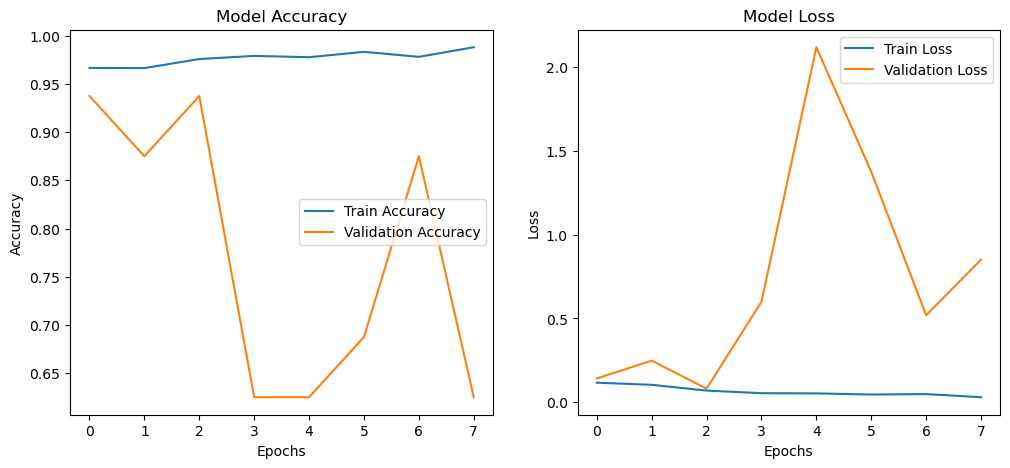

In [38]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Train Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

# Loss Plot
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Train Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [39]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

print(confusion_matrix(y_true, y_pred_classes))

print(classification_report(y_true, y_pred_classes))

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step
[[134 100]
 [  5 385]]
              precision    recall  f1-score   support

           0       0.96      0.57      0.72       234
           1       0.79      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.88      0.78      0.80       624
weighted avg       0.86      0.83      0.82       624



In [40]:
model.save("pneumonia_detection_model.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


In [41]:
def predict_xray(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0

    img = img.reshape(1, IMG_SIZE, IMG_SIZE, 1)

    prediction = model.predict(img)

    predicted_class = np.argmax(prediction)

    result = encoder.inverse_transform([predicted_class])

    plt.imshow(img.reshape(IMG_SIZE, IMG_SIZE), cmap='gray')

    plt.title(f"Prediction: {result[0]}")

    plt.axis("off")

    plt.show()

    print("Prediction:", result[0])

In [ ]:
predict_xray("tes")